## Import Libraries

In [22]:
# Basic libraries
import pandas as pd
import numpy as np

# Sklearn for model testing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# For visualization
import matplotlib.pyplot as plt

In [23]:
# Reading the dataset again -> since working on a new notebook, these steps are quite similar to the EDA & Hypothesis Testing
tourism = pd.read_csv("world_tourism_.csv")
quality = pd.read_csv("quality_of_life_indices_by_country.csv")

In [24]:
# on the tourism dataset -> 'country'
# on the quality -> 'Country'
tourism["country"] = tourism["country"].str.strip().str.lower()
quality["Country"] = quality["Country"].str.strip().str.lower()

In [25]:
# quality dataset has years like "2015", "2015/2"...
# I extract the main year part
quality["year"] = quality["Year"].astype(str).str.extract(r"(\d{4})").astype(int)

# Equalize each country column
quality = quality.rename(columns={"Country": "country"})

In [26]:
# Normalize the gdp with num of people
tourism["tourism_gdp_ratio"] = tourism["tourism_receipts"] / tourism["gdp"]

# Remove impossible or missing values
tourism = tourism.replace([np.inf, -np.inf], np.nan)
tourism_ml = tourism[["country", "year", "tourism_receipts", "gdp", "inflation", "unemployment", "tourism_gdp_ratio"]].dropna()

In [27]:
# Preparing quality dataset
# We are adding some new indecies to increase the project focus
# Main focus is stil safety vs affordibility
quality_features = [
    "country",
    "year",
    "Quality of Life Index",
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index"
]

quality_ml = quality[quality_features].copy()

# Converting numeric columns
for col in quality_ml.columns:
    if col not in ["country", "year"]:
        quality_ml[col] = pd.to_numeric(quality_ml[col], errors="coerce")

# Some years have two observations such as 2015 and 2015/2
# I take the average for each country-year pair
quality_ml = quality_ml.groupby(["country", "year"], as_index=False).mean()

In [28]:
# Merging tourism and quality datasets
df_ml = tourism_ml.merge(
    quality_ml,
    on=["country", "year"],
    how="inner"
)

df_ml = df_ml.dropna()

print("Final ML dataset shape:", df_ml.shape)
print(df_ml.head())

Final ML dataset shape: (319, 15)
     country  year  tourism_receipts           gdp  inflation  unemployment  \
0  argentina  2015      5.441000e+09  5.947493e+11  34.277224         7.579   
1  argentina  2016      5.466000e+09  5.575323e+11  34.277224         8.085   
2  argentina  2017      5.830000e+09  6.436284e+11  34.277224         8.347   
3  argentina  2018      5.999000e+09  5.248199e+11  34.277224         9.221   
4  argentina  2019      5.654000e+09  4.477547e+11  53.548304         9.843   

   tourism_gdp_ratio  Quality of Life Index  Purchasing Power Index  \
0           0.009148                  84.90                   71.50   
1           0.009804                 137.90                   68.10   
2           0.009058                 129.65                   54.60   
3           0.011431                 131.10                   60.85   
4           0.012627                 121.75                   53.50   

   Safety Index  Health Care Index  Cost of Living Index  \
0   

In [29]:
# Defining target and features
target = "tourism_gdp_ratio"

features = [
    "year",
    "inflation",
    "unemployment",
    "Quality of Life Index",
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index"
]

X = df_ml[features]
y = df_ml[target]

In [30]:
# Train and test split
# %80 of the data is used for training, %20 for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Defining a function for evaluation of each model
def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Performance")
    print("-------------------------")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

    return mae, rmse, r2

## Linear Regression



In [32]:
# Training a Linear Regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_model("Linear Regression", y_test, y_pred_linear)

Linear Regression Performance
-------------------------
MAE: 0.030893943572290077
RMSE: 0.0398749422209672
R²: 0.20064862183107324



In [33]:
# Linear Regression coefficients
linear_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.named_steps["model"].coef_
}).sort_values(by="Coefficient", ascending=False)

print("Linear Regression Coefficients:")
print(linear_coefficients)

Linear Regression Coefficients:
                           Feature  Coefficient
5                     Safety Index     0.014720
10                 Pollution Index     0.006024
2                     unemployment     0.004760
6                Health Care Index     0.004662
3            Quality of Life Index     0.003101
7             Cost of Living Index     0.001685
1                        inflation    -0.004000
9       Traffic Commute Time Index    -0.005269
8   Property Price to Income Ratio    -0.006948
0                             year    -0.009774
4           Purchasing Power Index    -0.019799


## Random Forest

In [34]:
# Training a Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

Random Forest Regressor Performance
-------------------------
MAE: 0.021172664625753547
RMSE: 0.030565906746736402
R²: 0.5303090826297076



## Feature Importance for Random Forest

In [35]:
# Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
                           Feature  Importance
2                     unemployment    0.233602
7             Cost of Living Index    0.202296
5                     Safety Index    0.129895
9       Traffic Commute Time Index    0.108322
10                 Pollution Index    0.068808
4           Purchasing Power Index    0.066845
8   Property Price to Income Ratio    0.059168
1                        inflation    0.048915
6                Health Care Index    0.039180
3            Quality of Life Index    0.021629
0                             year    0.021339


## Feature Importance Visualization

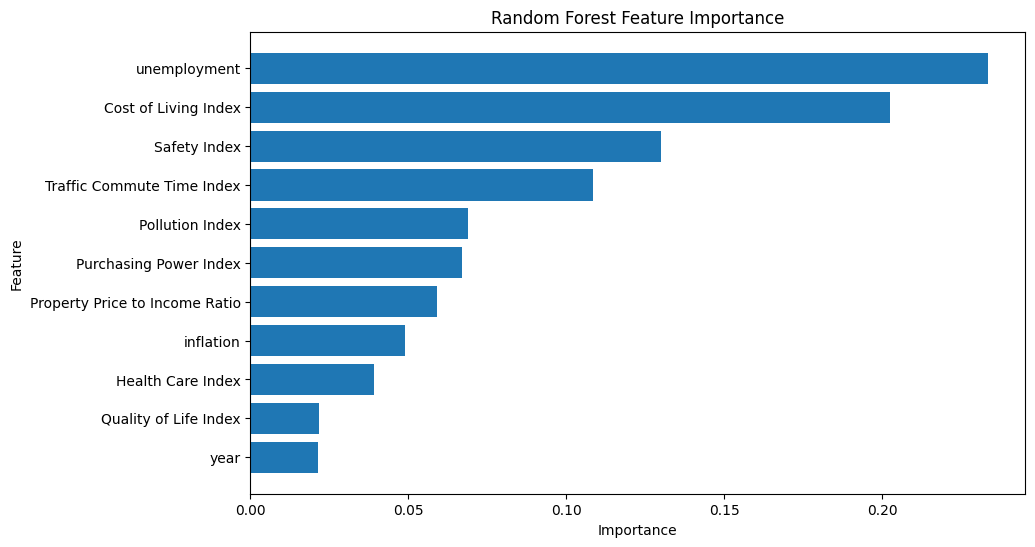

In [36]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Comparing Models

In [37]:
# Comparing model results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_results[0], rf_results[0]],
    "RMSE": [linear_results[1], rf_results[1]],
    "R2": [linear_results[2], rf_results[2]]
})

print("Model Comparison:")
print(results)

Model Comparison:
               Model       MAE      RMSE        R2
0  Linear Regression  0.030894  0.039875  0.200649
1      Random Forest  0.021173  0.030566  0.530309
